# 🔎 Fake News Detection — Naive Bayes

**Notebook experimental da Residência em Inteligência Artificial**

Este notebook documenta a avaliação do algoritmo **Naive Bayes** para classificação de notícias nas classes `fake` e `true`.

A análise foi organizada em três representações:

1. **Metadados**
2. **Título + Texto**
3. **Título + Texto + Metadados**

Também são investigadas duplicatas, sobreposição entre treinamento e teste, similaridade textual e o impacto da remoção de duplicatas exatas.

> **Objetivo:** documentar não apenas os resultados, mas também a metodologia, as decisões de pré-processamento, as limitações da avaliação e os próximos passos.

## 1. Visão geral da metodologia

A avaliação segue uma divisão **80% treinamento / 20% teste**, estratificada pela variável `classe` e com `random_state=42`.

### Modelos

- **Experimento 1:** Gaussian Naive Bayes sobre metadados numéricos.
- **Experimento 2:** Multinomial Naive Bayes sobre TF-IDF de título + texto.
- **Experimento 3:** Multinomial Naive Bayes sobre a combinação de TF-IDF + 19 metadados normalizados.

### Métricas

A classe `fake` é tratada como classe de interesse para:

- Accuracy
- Precision
- Recall
- F1-Score

As matrizes de confusão também são apresentadas para permitir a análise dos acertos e erros por classe.

## 2. Configuração do ambiente

In [ ]:
# ============================================================
# CONFIGURAÇÃO DAS DEPENDÊNCIAS PARA ANÁLISE POR URL
# ============================================================

!pip install -q spacy language-tool-python beautifulsoup4 requests
!python -m spacy download pt_core_news_sm -q

print("✅ Dependências para análise por URL instaladas.")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.2/63.2 kB 1.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.0/13.0 MB 83.1 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('pt_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
✅ Dependências para análise por URL instaladas.


In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.sparse import hstack, csr_matrix

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import GaussianNB, MultinomialNB
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from sklearn.metrics.pairwise import cosine_similarity

pd.set_option("display.max_colwidth", 120)
print("Ambiente configurado com sucesso.")
import spacy
import language_tool_python
from urllib.parse import urlparse
from bs4 import BeautifulSoup
import requests
import re

# NLP em português
nlp_pt = spacy.load("pt_core_news_sm")

# LanguageTool para erros ortográficos
try:
    tool_pt = language_tool_python.LanguageTool("pt-BR")
    language_tool_status = "disponível"
except Exception as erro:
    tool_pt = None
    language_tool_status = f"indisponível ({type(erro).__name__})"

print("spaCy:", "OK")
print("LanguageTool:", language_tool_status)


Ambiente configurado com sucesso.


spaCy: OK
LanguageTool: disponível


## 3. Carregamento e caracterização do dataset

In [ ]:
CAMINHO_DATASET = "/content/DATASET_TERCEIROGENITO_V1_URL_UNIFORME_PT.csv"

df = pd.read_csv(
    CAMINHO_DATASET,
    sep=";",
    encoding="utf-8-sig"
)

print("=" * 65)
print("DATASET")
print("=" * 65)
print(f"Linhas : {len(df):,}".replace(",", "."))
print(f"Colunas: {len(df.columns):,}".replace(",", "."))
print("\nDistribuição das classes:")
display(
    df["classe"]
    .value_counts()
    .rename_axis("classe")
    .to_frame("quantidade")
)

DATASET
Linhas : 18.217
Colunas: 45

Distribuição das classes:


,quantidade
classe,
true,13513
fake,4704


,Quantidade,Percentual
classe,,
true,13513,74.18
fake,4704,25.82


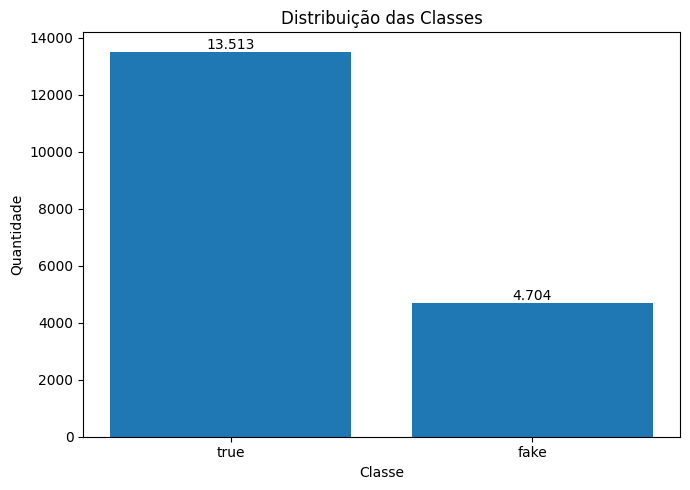

In [ ]:
distribuicao = df["classe"].value_counts()

percentuais = (
    df["classe"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

resumo_classes = pd.DataFrame({
    "Quantidade": distribuicao,
    "Percentual": percentuais
})

display(resumo_classes)

plt.figure(figsize=(7, 5))
barras = plt.bar(distribuicao.index, distribuicao.values)

plt.title("Distribuição das Classes")
plt.xlabel("Classe")
plt.ylabel("Quantidade")
plt.xticks(rotation=0)

for barra, valor in zip(barras, distribuicao.values):
    plt.text(
        barra.get_x() + barra.get_width() / 2,
        valor,
        f"{valor:,}".replace(",", "."),
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

### 3.1 Observação sobre o balanceamento

O dataset possui mais registros `true` do que `fake`. Por isso, a **accuracy isolada não é suficiente** para avaliar o comportamento do modelo. Precision, recall e F1-Score da classe `fake` são acompanhados separadamente.

## 4. Preparação comum dos dados textuais

In [ ]:
dados_texto = df[["titulo", "texto", "classe"]].copy()

dados_texto["titulo"] = dados_texto["titulo"].fillna("").astype(str)
dados_texto["texto"] = dados_texto["texto"].fillna("").astype(str)

dados_texto["conteudo"] = (
    dados_texto["titulo"] + " " + dados_texto["texto"]
).str.strip()

dados_texto = dados_texto[
    dados_texto["conteudo"] != ""
].copy()

print(f"Registros com conteúdo textual: {len(dados_texto):,}".replace(",", "."))
display(dados_texto[["titulo", "classe", "conteudo"]].head(3))

Registros com conteúdo textual: 18.217


,titulo,classe,conteudo
0,"Mesmo com alta do dólar, gastos de brasileiros no exterior batem recorde",true,"Mesmo com alta do dólar, gastos de brasileiros no exterior batem recorde A alta de 15% no dólar em 2013, a maior dos..."
1,"Para Dilma, é 'apressada' a tese de que emergentes perderão dinamismo",true,"Para Dilma, é 'apressada' a tese de que emergentes perderão dinamismo A presidente Dilma Rousseff afirmou nesta sext..."
2,"'Temos sido capazes de reduzir a inflação', diz Tombini em Davos",true,"'Temos sido capazes de reduzir a inflação', diz Tombini em Davos participa de debate sobre política monetária em\nDa..."


## 5. Experimento 1 — Naive Bayes com metadados

São utilizadas 19 características estruturais e linguísticas. Valores ausentes são preenchidos pela mediana calculada no treinamento e as features são padronizadas antes do Gaussian Naive Bayes.

In [ ]:
# ============================================================
# EXPERIMENTO 1 — METADADOS
# ============================================================

features_meta = [
    "qtd_links_externos",
    "qtd_dominios_externos",
    "num_tokens",
    "num_palavras",
    "num_types",
    "num_verbos",
    "num_substantivos",
    "num_adjetivos",
    "num_adverbios",
    "num_pronomes",
    "num_verbos_subjuntivo_imperativo",
    "num_palavras_maiusculas",
    "num_caracteres",
    "comprimento_medio_sentenca",
    "comprimento_medio_palavra",
    "percentual_erros_ortograficos",
    "emotividade",
    "diversidade_lexical",
    "coerencia_titulos_pct"
]

dados_meta = df[features_meta + ["classe"]].copy()
X_meta = dados_meta[features_meta].apply(pd.to_numeric, errors="coerce")
y_meta = dados_meta["classe"]

X_train_meta, X_test_meta, y_train_meta, y_test_meta = train_test_split(
    X_meta,
    y_meta,
    test_size=0.20,
    random_state=42,
    stratify=y_meta
)

modelo_meta = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("nb", GaussianNB())
])

modelo_meta.fit(X_train_meta, y_train_meta)
y_pred_meta = modelo_meta.predict(X_test_meta)

accuracy_meta = accuracy_score(y_test_meta, y_pred_meta)
precision_meta = precision_score(y_test_meta, y_pred_meta, pos_label="fake")
recall_meta = recall_score(y_test_meta, y_pred_meta, pos_label="fake")
f1_meta = f1_score(y_test_meta, y_pred_meta, pos_label="fake")

print("=" * 65)
print("EXPERIMENTO 1 — METADADOS")
print("=" * 65)
print(f"Total de registros : {len(dados_meta):,}".replace(",", "."))
print(f"Treinamento        : {len(X_train_meta):,}".replace(",", "."))
print(f"Teste              : {len(X_test_meta):,}".replace(",", "."))
print(f"\nAccuracy        : {accuracy_meta:.2%}")
print(f"Precision (fake): {precision_meta:.2%}")
print(f"Recall (fake)   : {recall_meta:.2%}")
print(f"F1-Score (fake) : {f1_meta:.2%}")

EXPERIMENTO 1 — METADADOS
Total de registros : 18.217
Treinamento        : 14.573
Teste              : 3.644

Accuracy        : 73.16%
Precision (fake): 47.67%
Recall (fake)   : 40.28%
F1-Score (fake) : 43.66%


Matriz de confusão:
[[ 379  562]
 [ 416 2287]]


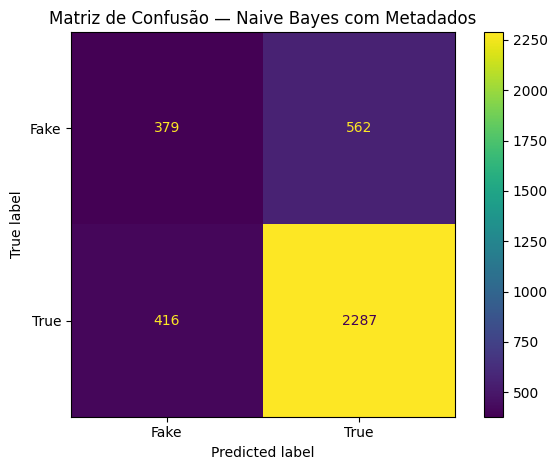


Acertos e erros:
Fake acertadas : 379
Fake erradas   : 562
True acertadas : 2287
True erradas   : 416


In [ ]:
cm_meta = confusion_matrix(
    y_test_meta,
    y_pred_meta,
    labels=["fake", "true"]
)

print("Matriz de confusão:")
print(cm_meta)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_meta,
    display_labels=["Fake", "True"]
)
disp.plot(values_format="d")
plt.title("Matriz de Confusão — Naive Bayes com Metadados")
plt.tight_layout()
plt.show()

fake_acertos_meta = cm_meta[0, 0]
fake_erros_meta = cm_meta[0, 1]
true_acertos_meta = cm_meta[1, 1]
true_erros_meta = cm_meta[1, 0]

print("\nAcertos e erros:")
print(f"Fake acertadas : {fake_acertos_meta}")
print(f"Fake erradas   : {fake_erros_meta}")
print(f"True acertadas : {true_acertos_meta}")
print(f"True erradas   : {true_erros_meta}")

### Interpretação

O modelo de metadados apresentou **73,16% de accuracy** e **43,66% de F1-Score para `fake`** na configuração utilizada na comparação principal.

Esse resultado indica que, isoladamente, as características estruturais/linguísticas utilizadas não reproduzem o mesmo poder discriminativo observado quando o conteúdo textual é incorporado.

> **Nota metodológica:** uma configuração preliminar de metadados havia incluído também variáveis relacionadas à coleta (`codigo_http`, `quantidade_redirects` e `tempo_ms`) e apresentou 87,87% de accuracy. Essa configuração não é usada na comparação principal, que utiliza apenas as 19 features estruturais/linguísticas.

## 6. Experimento 2 — Naive Bayes com título + texto

In [ ]:
# ============================================================
# EXPERIMENTO 2 — TÍTULO + TEXTO
# ============================================================

dados_texto = df[["titulo", "texto", "classe"]].copy()

dados_texto["titulo"] = dados_texto["titulo"].fillna("").astype(str)
dados_texto["texto"] = dados_texto["texto"].fillna("").astype(str)

dados_texto["conteudo"] = (
    dados_texto["titulo"] + " " + dados_texto["texto"]
).str.strip()

dados_texto = dados_texto[dados_texto["conteudo"] != ""].copy()

X_texto = dados_texto["conteudo"]
y_texto = dados_texto["classe"]

# A divisão é feita uma única vez e será reutilizada nos experimentos
# textuais para manter as condições de comparação.
idx_train_texto, idx_test_texto = train_test_split(
    dados_texto.index,
    test_size=0.20,
    random_state=42,
    stratify=y_texto
)

treino_texto = dados_texto.loc[idx_train_texto]
teste_texto = dados_texto.loc[idx_test_texto]

X_train_texto = treino_texto["conteudo"]
X_test_texto = teste_texto["conteudo"]
y_train_texto = treino_texto["classe"]
y_test_texto = teste_texto["classe"]

print("=" * 65)
print("EXPERIMENTO 2 — TÍTULO + TEXTO")
print("=" * 65)
print(f"Total de registros : {len(dados_texto):,}".replace(",", "."))
print(f"Treinamento        : {len(treino_texto):,}".replace(",", "."))
print(f"Teste              : {len(teste_texto):,}".replace(",", "."))
print("\nDistribuição no treinamento:")
print(y_train_texto.value_counts())
print("\nDistribuição no teste:")
print(y_test_texto.value_counts())

# ------------------------------------------------------------
# TF-IDF
# ------------------------------------------------------------

vectorizer_texto = TfidfVectorizer(
    lowercase=True,
    strip_accents="unicode",
    max_features=100000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

X_train_texto_tfidf = vectorizer_texto.fit_transform(X_train_texto)
X_test_texto_tfidf = vectorizer_texto.transform(X_test_texto)

print(f"\nFeatures TF-IDF: {X_train_texto_tfidf.shape[1]:,}".replace(",", "."))

# ------------------------------------------------------------
# Modelo
# ------------------------------------------------------------

modelo_texto = MultinomialNB()
modelo_texto.fit(X_train_texto_tfidf, y_train_texto)

y_pred_texto = modelo_texto.predict(X_test_texto_tfidf)

accuracy_texto = accuracy_score(y_test_texto, y_pred_texto)
precision_texto = precision_score(y_test_texto, y_pred_texto, pos_label="fake")
recall_texto = recall_score(y_test_texto, y_pred_texto, pos_label="fake")
f1_texto = f1_score(y_test_texto, y_pred_texto, pos_label="fake")

print("\nResultados:")
print(f"Accuracy        : {accuracy_texto:.2%}")
print(f"Precision (fake): {precision_texto:.2%}")
print(f"Recall (fake)   : {recall_texto:.2%}")
print(f"F1-Score (fake) : {f1_texto:.2%}")

EXPERIMENTO 2 — TÍTULO + TEXTO
Total de registros : 18.217
Treinamento        : 14.573
Teste              : 3.644

Distribuição no treinamento:
classe
true    10810
fake     3763
Name: count, dtype: int64

Distribuição no teste:
classe
true    2703
fake     941
Name: count, dtype: int64

Features TF-IDF: 100.000

Resultados:
Accuracy        : 98.93%
Precision (fake): 98.60%
Recall (fake)   : 97.24%
F1-Score (fake) : 97.91%


Matriz de confusão:
[[ 915   26]
 [  13 2690]]


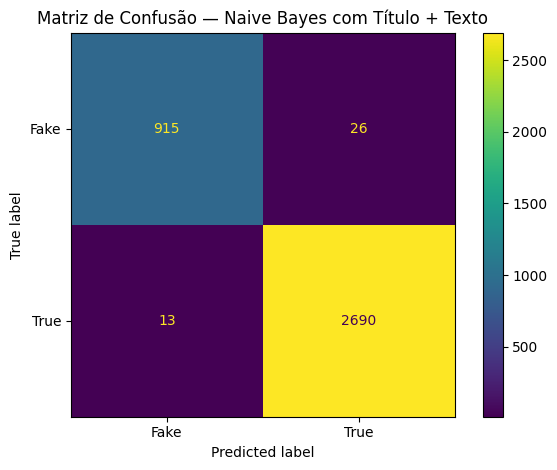


Acertos e erros:
Fake acertadas : 915
Fake erradas   : 26
True acertadas : 2690
True erradas   : 13

Total de acertos: 3605
Total de erros  : 39


In [ ]:
# Avaliação detalhada do Experimento 2

cm_texto = confusion_matrix(
    y_test_texto,
    y_pred_texto,
    labels=["fake", "true"]
)

print("Matriz de confusão:")
print(cm_texto)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_texto,
    display_labels=["Fake", "True"]
)
disp.plot(values_format="d")
plt.title("Matriz de Confusão — Naive Bayes com Título + Texto")
plt.tight_layout()
plt.show()

fake_acertos_texto = cm_texto[0, 0]
fake_erros_texto = cm_texto[0, 1]
true_acertos_texto = cm_texto[1, 1]
true_erros_texto = cm_texto[1, 0]

print("\nAcertos e erros:")
print(f"Fake acertadas : {fake_acertos_texto}")
print(f"Fake erradas   : {fake_erros_texto}")
print(f"True acertadas : {true_acertos_texto}")
print(f"True erradas   : {true_erros_texto}")
print(f"\nTotal de acertos: {fake_acertos_texto + true_acertos_texto}")
print(f"Total de erros  : {fake_erros_texto + true_erros_texto}")

### Interpretação

O conteúdo textual foi representado por TF-IDF, com unigramas e bigramas e limite de até 100.000 características.

O resultado observado foi **98,93% de accuracy**, com **97,91% de F1-Score para `fake`**.

Esse resultado é expressivo, mas posteriormente foi identificada sobreposição de conteúdos e alta similaridade entre exemplos de treinamento e teste. Portanto, o resultado original deve ser interpretado junto com a análise de duplicatas e possível vazamento de informação.

## 7. Experimento 3 — Título + Texto + Metadados

In [ ]:
# ============================================================
# EXPERIMENTO 3 — TÍTULO + TEXTO + METADADOS
# ============================================================

dados_combinados = df[
    ["titulo", "texto"] + features_meta + ["classe"]
].copy()

dados_combinados["titulo"] = dados_combinados["titulo"].fillna("").astype(str)
dados_combinados["texto"] = dados_combinados["texto"].fillna("").astype(str)

dados_combinados["conteudo"] = (
    dados_combinados["titulo"] + " " + dados_combinados["texto"]
).str.strip()

dados_combinados = dados_combinados[
    dados_combinados["conteudo"] != ""
].copy()

# Mesma estratégia de divisão: 80/20, estratificada, random_state=42.
idx_train_comb, idx_test_comb = train_test_split(
    dados_combinados.index,
    test_size=0.20,
    random_state=42,
    stratify=dados_combinados["classe"]
)

treino_comb = dados_combinados.loc[idx_train_comb]
teste_comb = dados_combinados.loc[idx_test_comb]

# ------------------------------------------------------------
# Texto → TF-IDF
# ------------------------------------------------------------

vectorizer_comb = TfidfVectorizer(
    lowercase=True,
    strip_accents="unicode",
    max_features=100000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

X_texto_train_comb = vectorizer_comb.fit_transform(treino_comb["conteudo"])
X_texto_test_comb = vectorizer_comb.transform(teste_comb["conteudo"])

# ------------------------------------------------------------
# Metadados → imputação + MinMax
# ------------------------------------------------------------

X_meta_train_comb = treino_comb[features_meta].apply(pd.to_numeric, errors="coerce")
X_meta_test_comb = teste_comb[features_meta].apply(pd.to_numeric, errors="coerce")

imputer_comb = SimpleImputer(strategy="median")
X_meta_train_comb = imputer_comb.fit_transform(X_meta_train_comb)
X_meta_test_comb = imputer_comb.transform(X_meta_test_comb)

scaler_comb = MinMaxScaler()
X_meta_train_comb = scaler_comb.fit_transform(X_meta_train_comb)
X_meta_test_comb = scaler_comb.transform(X_meta_test_comb)

X_meta_train_comb = csr_matrix(X_meta_train_comb)
X_meta_test_comb = csr_matrix(X_meta_test_comb)

# ------------------------------------------------------------
# Combinação
# ------------------------------------------------------------

X_train_combinado = hstack([
    X_texto_train_comb,
    X_meta_train_comb
]).tocsr()

X_test_combinado = hstack([
    X_texto_test_comb,
    X_meta_test_comb
]).tocsr()

y_train_combinado = treino_comb["classe"]
y_test_combinado = teste_comb["classe"]

print("=" * 65)
print("EXPERIMENTO 3 — TÍTULO + TEXTO + METADADOS")
print("=" * 65)
print(f"Total de registros : {len(dados_combinados):,}".replace(",", "."))
print(f"Treinamento        : {len(treino_comb):,}".replace(",", "."))
print(f"Teste              : {len(teste_comb):,}".replace(",", "."))
print(f"\nFeatures textuais  : {X_texto_train_comb.shape[1]:,}".replace(",", "."))
print(f"Features metadados : {len(features_meta):,}".replace(",", "."))
print(f"Features finais    : {X_train_combinado.shape[1]:,}".replace(",", "."))

# ------------------------------------------------------------
# Modelo
# ------------------------------------------------------------

modelo_combinado = MultinomialNB()
modelo_combinado.fit(X_train_combinado, y_train_combinado)

y_pred_combinado = modelo_combinado.predict(X_test_combinado)

accuracy_combinado = accuracy_score(y_test_combinado, y_pred_combinado)
precision_combinado = precision_score(y_test_combinado, y_pred_combinado, pos_label="fake")
recall_combinado = recall_score(y_test_combinado, y_pred_combinado, pos_label="fake")
f1_combinado = f1_score(y_test_combinado, y_pred_combinado, pos_label="fake")

print("\nResultados:")
print(f"Accuracy        : {accuracy_combinado:.2%}")
print(f"Precision (fake): {precision_combinado:.2%}")
print(f"Recall (fake)   : {recall_combinado:.2%}")
print(f"F1-Score (fake) : {f1_combinado:.2%}")

EXPERIMENTO 3 — TÍTULO + TEXTO + METADADOS
Total de registros : 18.217
Treinamento        : 14.573
Teste              : 3.644

Features textuais  : 100.000
Features metadados : 19
Features finais    : 100.019

Resultados:
Accuracy        : 98.85%
Precision (fake): 99.78%
Recall (fake)   : 95.75%
F1-Score (fake) : 97.72%


Matriz de confusão:
[[ 901   40]
 [   2 2701]]


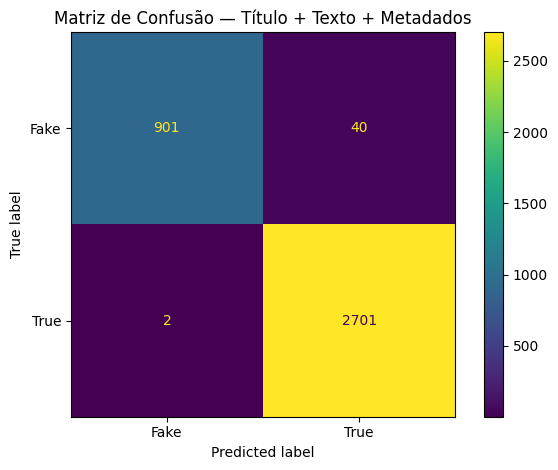


Acertos e erros:
Fake acertadas : 901
Fake erradas   : 40
True acertadas : 2701
True erradas   : 2

Total de acertos: 3602
Total de erros  : 42


In [ ]:
cm_combinado = confusion_matrix(
    y_test_combinado,
    y_pred_combinado,
    labels=["fake", "true"]
)

print("Matriz de confusão:")
print(cm_combinado)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_combinado,
    display_labels=["Fake", "True"]
)
disp.plot(values_format="d")
plt.title("Matriz de Confusão — Título + Texto + Metadados")
plt.tight_layout()
plt.show()

fake_acertos_comb = cm_combinado[0, 0]
fake_erros_comb = cm_combinado[0, 1]
true_acertos_comb = cm_combinado[1, 1]
true_erros_comb = cm_combinado[1, 0]

print("\nAcertos e erros:")
print(f"Fake acertadas : {fake_acertos_comb}")
print(f"Fake erradas   : {fake_erros_comb}")
print(f"True acertadas : {true_acertos_comb}")
print(f"True erradas   : {true_erros_comb}")
print(f"\nTotal de acertos: {fake_acertos_comb + true_acertos_comb}")
print(f"Total de erros  : {fake_erros_comb + true_erros_comb}")

### Interpretação

Neste experimento, o conteúdo textual e os 19 metadados são combinados em uma única representação.

- **100.000 features** vêm do TF-IDF.
- **19 features** vêm dos metadados.
- Total: **100.019 features**.

O resultado observado foi **98,85% de accuracy**, com **99,78% de precision**, **95,75% de recall** e **97,72% de F1-Score** para `fake`.

A comparação com o Experimento 2 mostra que a inclusão dos metadados não aumentou a accuracy global nessa configuração, embora tenha alterado o equilíbrio entre precision e recall da classe `fake`.

## 8. Comparação dos três experimentos

,Modelo,Accuracy,Precision (Fake),Recall (Fake),F1-Score (Fake)
0,Metadados,73.16%,47.67%,40.28%,43.66%
1,Título + Texto,98.93%,98.60%,97.24%,97.91%
2,Título + Texto + Metadados,98.85%,99.78%,95.75%,97.72%


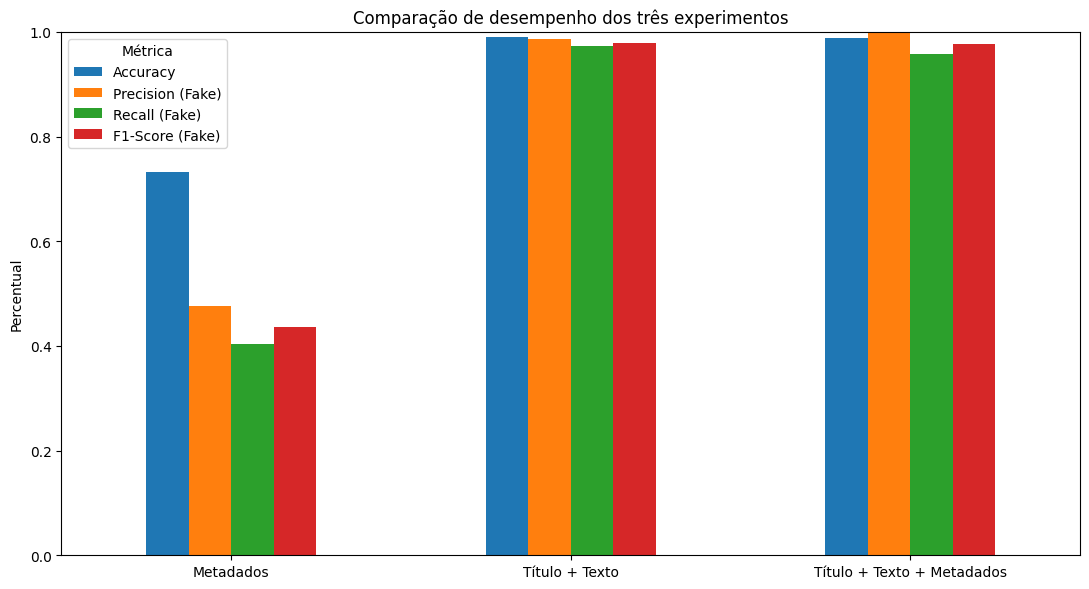

In [ ]:
# ============================================================
# COMPARAÇÃO CONSOLIDADA
# ============================================================

comparacao_modelos = pd.DataFrame({
    "Modelo": [
        "Metadados",
        "Título + Texto",
        "Título + Texto + Metadados"
    ],
    "Accuracy": [
        accuracy_meta,
        accuracy_texto,
        accuracy_combinado
    ],
    "Precision (Fake)": [
        precision_meta,
        precision_texto,
        precision_combinado
    ],
    "Recall (Fake)": [
        recall_meta,
        recall_texto,
        recall_combinado
    ],
    "F1-Score (Fake)": [
        f1_meta,
        f1_texto,
        f1_combinado
    ]
})

display(
    comparacao_modelos.style.format({
        "Accuracy": "{:.2%}",
        "Precision (Fake)": "{:.2%}",
        "Recall (Fake)": "{:.2%}",
        "F1-Score (Fake)": "{:.2%}"
    })
)

# Gráfico de métricas
ax = comparacao_modelos.set_index("Modelo").plot(
    kind="bar",
    figsize=(11, 6)
)
ax.set_title("Comparação de desempenho dos três experimentos")
ax.set_xlabel("")
ax.set_ylabel("Percentual")
ax.set_ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Métrica")
plt.tight_layout()
plt.show()

### Leitura da comparação

A tabela deve ser interpretada considerando que:

- o experimento de metadados usa **GaussianNB**;
- os experimentos textuais usam **MultinomialNB**;
- os três utilizam a mesma proporção de treinamento/teste e `random_state=42`;
- a avaliação ainda está sujeita às limitações identificadas na análise de duplicatas.

O objetivo desta comparação é descrever o comportamento das diferentes representações dos dados, e não tratar uma única métrica como suficiente para determinar a qualidade geral do sistema.

## 9. Investigação de duplicatas

In [ ]:
# ============================================================
# INVESTIGAÇÃO DE DUPLICATAS E POSSÍVEL SOBREPOSIÇÃO
# ============================================================

df_dup = dados_texto.copy()

duplicatas_conteudo = df_dup[
    df_dup["conteudo"].duplicated(keep=False)
].copy()

print("=" * 65)
print("DUPLICATAS EXATAS")
print("=" * 65)
print(f"Registros envolvidos : {len(duplicatas_conteudo):,}".replace(",", "."))
print(f"Grupos duplicados    : {duplicatas_conteudo['conteudo'].nunique():,}".replace(",", "."))

duplicatas_titulo = df_dup[
    df_dup["titulo"].duplicated(keep=False)
].copy()

print("\n" + "=" * 65)
print("DUPLICATAS DE TÍTULO")
print("=" * 65)
print(f"Registros envolvidos : {len(duplicatas_titulo):,}".replace(",", "."))
print(f"Títulos repetidos    : {duplicatas_titulo['titulo'].nunique():,}".replace(",", "."))

# Conteúdo exatamente igual entre treino e teste.
conteudos_treino = set(X_train_texto.astype(str))
conteudos_teste = set(X_test_texto.astype(str))
sobreposicao_conteudo = conteudos_treino.intersection(conteudos_teste)

titulos_treino = set(treino_texto["titulo"].astype(str))
titulos_teste = set(teste_texto["titulo"].astype(str))
sobreposicao_titulo = titulos_treino.intersection(titulos_teste)

print("\n" + "=" * 65)
print("SOBREPOSIÇÃO TREINO × TESTE")
print("=" * 65)
print(f"Conteúdos presentes nos dois conjuntos: {len(sobreposicao_conteudo):,}".replace(",", "."))
print(f"Títulos presentes nos dois conjuntos  : {len(sobreposicao_titulo):,}".replace(",", "."))

DUPLICATAS EXATAS
Registros envolvidos : 137
Grupos duplicados    : 68

DUPLICATAS DE TÍTULO
Registros envolvidos : 153
Títulos repetidos    : 75

SOBREPOSIÇÃO TREINO × TESTE
Conteúdos presentes nos dois conjuntos: 22
Títulos presentes nos dois conjuntos  : 26


In [ ]:
# Similaridade aproximada: compara uma amostra do teste contra uma amostra do treino.
# O objetivo é investigar conteúdos muito semelhantes, além das duplicatas exatas.

MAX_AMOSTRA = min(
    3000,
    X_train_texto_tfidf.shape[0],
    X_test_texto_tfidf.shape[0]
)

X_train_amostra = X_train_texto_tfidf[:MAX_AMOSTRA]
X_test_amostra = X_test_texto_tfidf[:MAX_AMOSTRA]

similaridades = cosine_similarity(
    X_test_amostra,
    X_train_amostra
)

maior_similaridade = similaridades.max(axis=1)

print("=" * 65)
print("SIMILARIDADE ENTRE TREINO E TESTE")
print("=" * 65)

print(
    f"Amostra analisada: "
    f"{MAX_AMOSTRA:,} × {MAX_AMOSTRA:,}"
    .replace(",", ".")
)

print(
    f"Maior similaridade observada: "
    f"{maior_similaridade.max():.2f}"
)

print(
    f"Média das maiores similaridades: "
    f"{maior_similaridade.mean():.2f}"
)

top_n = min(10, similaridades.size)

indices_top = np.dstack(
    np.unravel_index(
        np.argsort(similaridades.ravel())[-top_n:],
        similaridades.shape
    )
)[0][::-1]

print("\nPares mais semelhantes:")

for idx_teste, idx_treino in indices_top:

    print("-" * 65)

    print(
        f"Similaridade: "
        f"{similaridades[idx_teste, idx_treino]:.2f}"
    )

    print(
        "TESTE :",
        X_test_texto.iloc[idx_teste][:180]
    )

    print(
        "TREINO:",
        X_train_texto.iloc[idx_treino][:180]
    )

SIMILARIDADE ENTRE TREINO E TESTE
Amostra analisada: 3.000 × 3.000
Maior similaridade observada: 1.00
Média das maiores similaridades: 0.20

Pares mais semelhantes:
-----------------------------------------------------------------
Similaridade: 1.00
TESTE : Fachin manda para a Justiça Federal do DF denúncia de organização criminosa contra Lula, Dilma e ex-ministros | G1 O ministro Edson Fachin, do Supremo Tribunal Federal (STF), deter
TREINO: Fachin manda para a Justiça Federal do DF denúncia de organização criminosa contra Lula, Dilma e ex-ministros | G1 O ministro Edson Fachin, do Supremo Tribunal Federal (STF), deter
-----------------------------------------------------------------
Similaridade: 1.00
TESTE : Temer adia viagem a São Paulo e se reúne no Jaburu com cúpula do PSDB | G1 O presidente da República, Michel Temer, cancelou nesta segunda-feira (12) a participação em um evento em
TREINO: Temer adia viagem a São Paulo e se reúne no Jaburu com cúpula do PSDB | G1 O presidente da

### Por que esta etapa é importante?

Se um conteúdo igual ou muito semelhante aparecer em treinamento e teste, o modelo pode receber no teste uma informação praticamente já observada durante o treinamento. Isso pode elevar artificialmente as métricas e reduzir a capacidade de generalização que a avaliação pretende medir.

Por isso, a investigação considera tanto **duplicatas exatas** quanto **similaridade textual**.

## 10. Retreinamento após remoção de duplicatas exatas

In [ ]:
# ============================================================
# RETREINAMENTO APÓS REMOÇÃO DE DUPLICATAS EXATAS
# ============================================================

antes = len(dados_texto)

dados_sem_duplicatas = dados_texto.drop_duplicates(
    subset=["conteudo"]
).copy()

depois = len(dados_sem_duplicatas)

print("=" * 65)
print("DATASET SEM DUPLICATAS")
print("=" * 65)
print(f"Antes             : {antes:,}".replace(",", "."))
print(f"Depois            : {depois:,}".replace(",", "."))
print(f"Duplicatas removidas: {antes - depois:,}".replace(",", "."))

X_limpo = dados_sem_duplicatas["conteudo"]
y_limpo = dados_sem_duplicatas["classe"]

X_train_limpo, X_test_limpo, y_train_limpo, y_test_limpo = train_test_split(
    X_limpo,
    y_limpo,
    test_size=0.20,
    random_state=42,
    stratify=y_limpo
)

vectorizer_limpo = TfidfVectorizer(
    lowercase=True,
    strip_accents="unicode",
    max_features=100000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

X_train_limpo_tfidf = vectorizer_limpo.fit_transform(X_train_limpo)
X_test_limpo_tfidf = vectorizer_limpo.transform(X_test_limpo)

modelo_limpo = MultinomialNB()
modelo_limpo.fit(X_train_limpo_tfidf, y_train_limpo)

y_pred_limpo = modelo_limpo.predict(X_test_limpo_tfidf)

accuracy_limpo = accuracy_score(y_test_limpo, y_pred_limpo)
precision_limpo = precision_score(y_test_limpo, y_pred_limpo, pos_label="fake")
recall_limpo = recall_score(y_test_limpo, y_pred_limpo, pos_label="fake")
f1_limpo = f1_score(y_test_limpo, y_pred_limpo, pos_label="fake")

print("\nResultados sem duplicatas:")
print(f"Accuracy        : {accuracy_limpo:.2%}")
print(f"Precision (fake): {precision_limpo:.2%}")
print(f"Recall (fake)   : {recall_limpo:.2%}")
print(f"F1-Score (fake) : {f1_limpo:.2%}")

DATASET SEM DUPLICATAS
Antes             : 18.217
Depois            : 18.148
Duplicatas removidas: 69

Resultados sem duplicatas:
Accuracy        : 98.90%
Precision (fake): 98.60%
Recall (fake)   : 97.13%
F1-Score (fake) : 97.86%


,Métrica,Original,Sem duplicatas
0,Accuracy,98.93%,98.90%
1,Precision,98.60%,98.60%
2,Recall,97.24%,97.13%
3,F1-Score,97.91%,97.86%


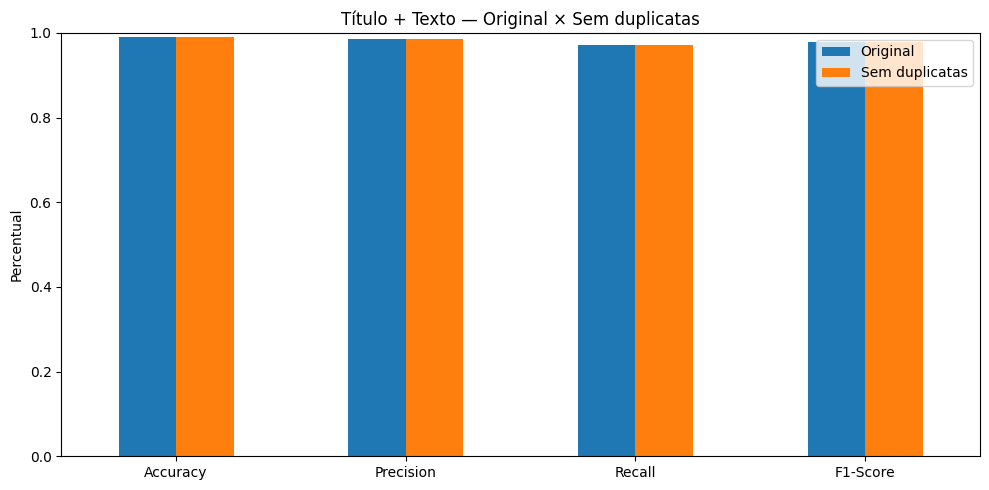

In [ ]:
# Comparação do experimento textual antes × depois da remoção de duplicatas

comparacao_duplicatas = pd.DataFrame({
    "Métrica": ["Accuracy", "Precision", "Recall", "F1-Score"],
    "Original": [
        accuracy_texto,
        precision_texto,
        recall_texto,
        f1_texto
    ],
    "Sem duplicatas": [
        accuracy_limpo,
        precision_limpo,
        recall_limpo,
        f1_limpo
    ]
})

display(
    comparacao_duplicatas.style.format({
        "Original": "{:.2%}",
        "Sem duplicatas": "{:.2%}"
    })
)

ax = comparacao_duplicatas.set_index("Métrica").plot(
    kind="bar",
    figsize=(10, 5)
)
ax.set_title("Título + Texto — Original × Sem duplicatas")
ax.set_xlabel("")
ax.set_ylabel("Percentual")
ax.set_ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Interpretação

A remoção das duplicatas exatas reduziu o dataset de **18.217 para 18.148 registros**, removendo **69 registros**.

O modelo textual passou de aproximadamente **98,93% para 98,90% de accuracy**, mantendo desempenho muito próximo. Isso indica que as duplicatas exatas removidas, isoladamente, não explicam o desempenho elevado.

Entretanto, a investigação de similaridade mostrou que ainda existem conteúdos muito semelhantes. Assim, o próximo passo metodológico é uma divisão por grupos de conteúdo ou outra estratégia que impeça exemplos semanticamente relacionados de atravessarem a fronteira treino/teste.

## 11. Análise geral e limitações

### Principais observações

**1. Conteúdo textual é altamente informativo neste dataset.**  
O modelo com título + texto apresentou desempenho muito superior ao modelo baseado apenas nos 19 metadados estruturais/linguísticos.

**2. A combinação com metadados não elevou a accuracy global.**  
O Experimento 3 apresentou 98,85%, muito próximo dos 98,93% do Experimento 2, mas com mudanças em precision e recall da classe `fake`.

**3. Duplicatas exatas não explicam sozinhas o desempenho.**  
A remoção de 69 registros teve pouco impacto nas métricas.

**4. Existe uma limitação mais importante: similaridade entre treino e teste.**  
Foram encontrados conteúdos/títulos sobrepostos e pares de notícias com alta similaridade. Isso pode introduzir vazamento de informação e deve ser controlado em uma avaliação posterior.

**5. A classificação não equivale a checagem factual.**  
O Naive Bayes aprende padrões presentes no dataset. Uma previsão `fake` ou `true` não substitui a verificação independente da informação.

## 12. Conclusão provisória

Os experimentos mostram que o Naive Bayes consegue obter alto desempenho quando o **conteúdo textual** é utilizado como representação das notícias. O uso isolado dos metadados apresentou desempenho consideravelmente menor na configuração principal, enquanto a combinação de texto e metadados produziu resultados próximos aos do modelo textual.

Antes de considerar os números como uma medida definitiva de generalização, é necessário controlar a sobreposição entre treinamento e teste. A próxima avaliação deve utilizar uma estratégia de divisão que agrupe conteúdos iguais ou semanticamente relacionados, além de manter métricas por classe e análise da matriz de confusão.

Assim, o notebook registra tanto os resultados positivos quanto as limitações metodológicas encontradas durante a investigação.

## 13. Aplicação prática — classificação por evidências das features


Esta etapa permite informar uma URL e analisar a página usando as **19 features estruturais e linguísticas do Experimento 1**.

**Fluxo:** URL → coleta HTML → extração do título/texto/links → cálculo das 19 features → Gaussian Naive Bayes → evidência individual de cada feature → índice percentual `TRUE` × `FAKE`.

### Como funciona o índice de evidências

Para cada feature, o valor da notícia é comparado às distribuições `TRUE` e `FAKE` aprendidas pelo GaussianNB.

`evidência = log P(feature | TRUE) − log P(feature | FAKE)`

- evidência positiva → a feature favorece `TRUE`;
- evidência negativa → a feature favorece `FAKE`.

A porcentagem exibida no resultado é baseada na **quantidade de features que favorecem cada classe**, e não no `predict_proba()` original do GaussianNB. Por exemplo, 14 features favoráveis a `TRUE` e 5 a `FAKE` resultam em **73,68% TRUE e 26,32% FAKE**.

> **Importante:** esse percentual representa a distribuição das evidências das features. Não é uma probabilidade calibrada de que a notícia seja verdadeira ou falsa.


In [ ]:
# ============================================================
# 13.1 EXTRAÇÃO DA NOTÍCIA A PARTIR DA URL
# ============================================================

def extrair_noticia_url(url):
    headers = {
        "User-Agent": (
            "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
            "AppleWebKit/537.36 (KHTML, like Gecko) "
            "Chrome/151.0 Safari/537.36"
        ),
        "Accept-Language": "pt-BR,pt;q=0.9,en;q=0.8"
    }

    try:
        resposta = requests.get(url, headers=headers, timeout=20)
    except requests.exceptions.Timeout:
        return None, "A página demorou muito para responder."
    except requests.exceptions.ConnectionError:
        return None, "Não foi possível estabelecer conexão com a página."
    except requests.exceptions.RequestException as erro:
        return None, f"Erro ao acessar a URL: {erro}"

    if resposta.status_code == 403:
        return None, "O site recusou o acesso automático (HTTP 403)."
    if resposta.status_code == 401:
        return None, "O site exige autenticação (HTTP 401)."
    if resposta.status_code == 404:
        return None, "A página não foi encontrada (HTTP 404)."
    if resposta.status_code >= 400:
        return None, f"O site retornou HTTP {resposta.status_code}."

    soup = BeautifulSoup(resposta.text, "html.parser")

    for elemento in soup(["script", "style", "noscript", "svg", "iframe"]):
        elemento.decompose()

    titulo = ""
    for seletor in [
        ("meta", {"property": "og:title"}),
        ("meta", {"name": "twitter:title"})
    ]:
        tag = soup.find(*seletor)
        if tag and tag.get("content"):
            titulo = tag["content"].strip()
            break

    if not titulo and soup.find("h1"):
        titulo = soup.find("h1").get_text(" ", strip=True)
    if not titulo and soup.title:
        titulo = soup.title.get_text(" ", strip=True)
    titulo = re.sub(r"\s+", " ", titulo).strip()

    autor = ""
    for attrs in [
        {"name": re.compile("^author$", re.I)},
        {"property": "article:author"}
    ]:
        tag = soup.find("meta", attrs=attrs)
        if tag and tag.get("content"):
            autor = tag["content"].strip()
            break

    data = ""
    for attrs in [
        {"property": "article:published_time"},
        {"property": "article:modified_time"},
        {"name": "date"}
    ]:
        tag = soup.find("meta", attrs=attrs)
        if tag and tag.get("content"):
            data = tag["content"].strip()
            break

    textos = []
    for p in soup.find_all("p"):
        trecho = re.sub(r"\s+", " ", p.get_text(" ", strip=True)).strip()
        if len(trecho) >= 30:
            textos.append(trecho)

    texto = re.sub(r"\s+", " ", " ".join(textos)).strip()

    dominio_origem = urlparse(url).netloc.lower().replace("www.", "")
    links_externos = 0
    dominios_externos = set()

    hrefs = [
        a.get("href", "").strip()
        for a in soup.find_all("a")
        if a.get("href")
    ]

    for href in hrefs:
        if not href.startswith(("http://", "https://")):
            continue

        dominio = urlparse(href).netloc.lower().replace("www.", "")

        if dominio and dominio != dominio_origem:
            links_externos += 1
            dominios_externos.add(dominio)

    return {
        "url": url,
        "titulo": titulo,
        "autor": autor,
        "data": data,
        "texto": texto,
        "qtd_links_externos": links_externos,
        "qtd_dominios_externos": len(dominios_externos),
        "status_http": resposta.status_code
    }, None


In [ ]:
# ============================================================
# 13.2 CÁLCULO DAS 19 FEATURES DA URL
# ============================================================

def calcular_features_url(dados):
    titulo = dados["titulo"]
    texto = dados["texto"]
    texto_completo = f"{titulo} {texto}".strip()

    palavras = re.findall(r"\b[\wÀ-ÿ]+\b", texto_completo, flags=re.UNICODE)
    num_palavras = len(palavras)
    num_tokens = num_palavras
    num_types = len(set(p.lower() for p in palavras))
    num_caracteres = len(texto_completo)

    sentencas = [
        s.strip() for s in re.split(r"[.!?]+", texto_completo) if s.strip()
    ]
    num_sentencas = max(len(sentencas), 1)

    comprimento_medio_sentenca = (
        num_palavras / num_sentencas if num_palavras else 0
    )
    comprimento_medio_palavra = (
        np.mean([len(p) for p in palavras]) if palavras else 0
    )

    palavras_maiusculas = [
        p for p in palavras if len(p) > 1 and p.isupper()
    ]

    # NLP — spaCy
    doc = nlp_pt(texto_completo)

    num_verbos = sum(1 for token in doc if token.pos_ == "VERB")
    num_substantivos = sum(
        1 for token in doc if token.pos_ in ("NOUN", "PROPN")
    )
    num_adjetivos = sum(1 for token in doc if token.pos_ == "ADJ")
    num_adverbios = sum(1 for token in doc if token.pos_ == "ADV")
    num_pronomes = sum(1 for token in doc if token.pos_ == "PRON")

    num_verbos_subjuntivo_imperativo = 0
    for token in doc:
        if token.pos_ != "VERB":
            continue
        moods = token.morph.get("Mood")
        if any(mood in ("Sub", "Imp") for mood in moods):
            num_verbos_subjuntivo_imperativo += 1

    # Emotividade
    denominador_emotividade = num_substantivos + num_verbos
    emotividade = (
        (num_adjetivos + num_adverbios) / denominador_emotividade
        if denominador_emotividade > 0 else 0
    )

    # Diversidade lexical
    tokens_conteudo = [
        token.lemma_.lower()
        for token in doc
        if token.pos_ in ("NOUN", "PROPN", "VERB", "ADJ", "ADV")
        and token.is_alpha
    ]
    diversidade_lexical = (
        len(set(tokens_conteudo)) / len(tokens_conteudo)
        if tokens_conteudo else 0
    )

    # Erros ortográficos
    if tool_pt is not None:
        try:
            erros = tool_pt.check(texto_completo)
            percentual_erros_ortograficos = (
                len(erros) / num_palavras * 100
                if num_palavras else 0
            )
        except Exception as erro:
            print(f"⚠️ Não foi possível executar a verificação ortográfica: {erro}")
            percentual_erros_ortograficos = np.nan
    else:
        percentual_erros_ortograficos = np.nan

    # Coerência título × conteúdo
    titulo_words = {
        p.lower()
        for p in re.findall(r"\b[\wÀ-ÿ]+\b", titulo, flags=re.UNICODE)
    }
    texto_words = {
        p.lower()
        for p in re.findall(r"\b[\wÀ-ÿ]+\b", texto, flags=re.UNICODE)
    }

    coerencia = (
        len(titulo_words & texto_words) / len(titulo_words) * 100
        if titulo_words else 0
    )

    return {
        "qtd_links_externos": dados["qtd_links_externos"],
        "qtd_dominios_externos": dados["qtd_dominios_externos"],
        "num_tokens": num_tokens,
        "num_palavras": num_palavras,
        "num_types": num_types,
        "num_verbos": num_verbos,
        "num_substantivos": num_substantivos,
        "num_adjetivos": num_adjetivos,
        "num_adverbios": num_adverbios,
        "num_pronomes": num_pronomes,
        "num_verbos_subjuntivo_imperativo": num_verbos_subjuntivo_imperativo,
        "num_palavras_maiusculas": len(palavras_maiusculas),
        "num_caracteres": num_caracteres,
        "comprimento_medio_sentenca": comprimento_medio_sentenca,
        "comprimento_medio_palavra": comprimento_medio_palavra,
        "percentual_erros_ortograficos": percentual_erros_ortograficos,
        "emotividade": emotividade,
        "diversidade_lexical": diversidade_lexical,
        "coerencia_titulos_pct": coerencia
    }


In [ ]:
# ============================================================
# 13.3 EVIDÊNCIA INDIVIDUAL DAS FEATURES
# ============================================================

def calcular_evidencias_features(features_url):
    # O Experimento 1 é:
    # imputação -> StandardScaler -> GaussianNB
    imputer_meta = modelo_meta.named_steps["imputer"]
    scaler_meta = modelo_meta.named_steps["scaler"]
    nb_meta = modelo_meta.named_steps["nb"]

    df_url = pd.DataFrame([features_url], columns=features_meta)
    valores_originais = df_url.iloc[0].copy()

    X_imp = imputer_meta.transform(df_url)
    X_scaled = scaler_meta.transform(X_imp)

    classes = [str(c).lower() for c in nb_meta.classes_]
    idx_true = classes.index("true")
    idx_fake = classes.index("fake")

    linhas = []

    for i, feature in enumerate(features_meta):
        x = X_scaled[0, i]

        var_true = max(nb_meta.var_[idx_true, i], 1e-12)
        var_fake = max(nb_meta.var_[idx_fake, i], 1e-12)

        log_like_true = -0.5 * (
            np.log(2 * np.pi * var_true)
            + ((x - nb_meta.theta_[idx_true, i]) ** 2) / var_true
        )

        log_like_fake = -0.5 * (
            np.log(2 * np.pi * var_fake)
            + ((x - nb_meta.theta_[idx_fake, i]) ** 2) / var_fake
        )

        evidencia = log_like_true - log_like_fake

        if evidencia > 0:
            classe = "TRUE"
        elif evidencia < 0:
            classe = "FAKE"
        else:
            classe = "NEUTRA"

        valor = valores_originais[feature]

        linhas.append({
            "feature": feature,
            "valor": valor,
            "evidencia": evidencia,
            "classe_evidencia": classe,
            "foi_imputada": pd.isna(valor)
        })

    return pd.DataFrame(linhas)


In [ ]:
# ============================================================
# 13.4 ANÁLISE COMPLETA DA URL
# ============================================================

def analisar_url(url):
    url = url.strip()

    if not url:
        print("❌ Nenhuma URL informada.")
        return None

    if not url.startswith(("http://", "https://")):
        print("❌ A URL precisa começar com http:// ou https://")
        return None

    print("🌐 Acessando a página...")
    dados, erro = extrair_noticia_url(url)

    if erro:
        print("\n⚠️ NÃO FOI POSSÍVEL ANALISAR")
        print("=" * 80)
        print(erro)
        return None

    texto_modelo = f"{dados['titulo']} {dados['texto']}".strip()

    if len(texto_modelo) < 100:
        print("\n⚠️ CONTEÚDO INSUFICIENTE")
        print("=" * 80)
        print("Não foi possível extrair texto suficiente da página.")
        return None

    features_url = calcular_features_url(dados)
    evidencias = calcular_evidencias_features(features_url)

    # Somente features realmente calculadas entram no índice.
    validas = evidencias[~evidencias["foi_imputada"]].copy()

    true_like = int((validas["classe_evidencia"] == "TRUE").sum())
    fake_like = int((validas["classe_evidencia"] == "FAKE").sum())
    neutras = int((validas["classe_evidencia"] == "NEUTRA").sum())

    total_direcionadas = true_like + fake_like

    percentual_true = (
        true_like / total_direcionadas * 100
        if total_direcionadas else 0
    )
    percentual_fake = (
        fake_like / total_direcionadas * 100
        if total_direcionadas else 0
    )

    if percentual_true > percentual_fake:
        classificacao = "TRUE"
    elif percentual_fake > percentual_true:
        classificacao = "FAKE"
    else:
        classificacao = "EQUILIBRADA"

    print("\n" + "=" * 80)
    print("🔎 ANÁLISE DA NOTÍCIA")
    print("=" * 80)
    print(f"\nTítulo: {dados['titulo'] or 'Não identificado'}")

    print("\n📊 ÍNDICE DE EVIDÊNCIAS")
    print("-" * 80)
    print(f"TRUE: {percentual_true:.2f}%")
    print(f"FAKE: {percentual_fake:.2f}%")
    print(f"\nFeatures favoráveis a TRUE: {true_like}")
    print(f"Features favoráveis a FAKE: {fake_like}")

    if neutras:
        print(f"Features neutras: {neutras}")

    print("\n🌐 INFORMAÇÕES DA PÁGINA")
    print("-" * 80)
    print(f"Autor:              {dados['autor'] or 'Não identificado'}")
    print(f"Data:               {dados['data'] or 'Não identificada'}")
    print(f"Links externos:     {dados['qtd_links_externos']}")
    print(f"Domínios externos:  {dados['qtd_dominios_externos']}")
    print(f"HTTP:               {dados['status_http']}")
    print(
        f"Texto extraído:     {len(dados['texto']):,} caracteres"
        .replace(",", ".")
    )

    print("\n🧩 FEATURES + EVIDÊNCIAS")
    print("-" * 80)

    nomes = {
        "qtd_links_externos": "Links externos",
        "qtd_dominios_externos": "Domínios externos",
        "num_tokens": "Tokens",
        "num_palavras": "Palavras",
        "num_types": "Types",
        "num_verbos": "Verbos",
        "num_substantivos": "Substantivos",
        "num_adjetivos": "Adjetivos",
        "num_adverbios": "Advérbios",
        "num_pronomes": "Pronomes",
        "num_verbos_subjuntivo_imperativo": "Verbos subj./imper.",
        "num_palavras_maiusculas": "Palavras maiúsculas",
        "num_caracteres": "Caracteres",
        "comprimento_medio_sentenca": "Comprimento médio sentença",
        "comprimento_medio_palavra": "Comprimento médio palavra",
        "percentual_erros_ortograficos": "Erros ortográficos",
        "emotividade": "Emotividade",
        "diversidade_lexical": "Diversidade lexical",
        "coerencia_titulos_pct": "Coerência título/conteúdo"
    }

    for _, row in evidencias.iterrows():
        nome = nomes.get(row["feature"], row["feature"])
        valor = row["valor"]
        classe = row["classe_evidencia"]
        evidencia = row["evidencia"]

        if pd.isna(valor):
            valor_formatado = "N/A"
        elif row["feature"] in {
            "percentual_erros_ortograficos",
            "coerencia_titulos_pct"
        }:
            valor_formatado = f"{float(valor):.2f}%"
        elif row["feature"] in {
            "comprimento_medio_sentenca",
            "comprimento_medio_palavra",
            "emotividade",
            "diversidade_lexical"
        }:
            valor_formatado = f"{float(valor):.2f}"
        else:
            valor_formatado = f"{int(round(float(valor)))}"

        print(
            f"{nome:<30} "
            f"{valor_formatado:>12}   "
            f"→ Evidência: {classe:<6} "
            f"({evidencia:+.2f})"
        )

    print("\n🧠 CLASSIFICAÇÃO POR EVIDÊNCIAS")
    print("-" * 80)
    print(f"Resultado: {classificacao}")
    print(
        "A classificação acima é baseada na proporção de features "
        "que favorecem cada classe."
    )

    print("\n⚠️ INTERPRETAÇÃO")
    print("-" * 80)
    print(
        "O índice TRUE/FAKE representa a distribuição das evidências "
        "das features e não uma probabilidade calibrada de veracidade."
    )
    print(
        "Uma feature que favorece FAKE não prova que a notícia seja falsa; "
        "ela apenas apresenta maior verossimilhança relativa para essa classe."
    )
    print("=" * 80)

    return {
        "dados": dados,
        "features": features_url,
        "evidencias": evidencias,
        "percentual_true": percentual_true,
        "percentual_fake": percentual_fake,
        "classificacao": classificacao
    }


In [ ]:
# ============================================================
# 13.5 🚀 DIGITE UMA URL PARA ANALISAR
# ============================================================

url_teste = input(
    "🔗 Cole a URL da notícia que deseja analisar:\n\n> "
)

resultado_url = analisar_url(url_teste)


🔗 Cole a URL da notícia que deseja analisar:

> https://www.boatos.org/politica/tarcisio-lancou-castores-e-recuperou-o-rio-tiete-em-sao-paulo.html?utm_source=chatgpt.com
🌐 Acessando a página...

🔎 ANÁLISE DA NOTÍCIA

Título: Tarcísio lançou castores e recuperou o Rio Tietê em São Paulo?

📊 ÍNDICE DE EVIDÊNCIAS
--------------------------------------------------------------------------------
TRUE: 61.11%
FAKE: 38.89%

Features favoráveis a TRUE: 11
Features favoráveis a FAKE: 7
Features neutras: 1

🌐 INFORMAÇÕES DA PÁGINA
--------------------------------------------------------------------------------
Autor:              Edgard Matsuki
Data:               2026-06-23T18:21:43+00:00
Links externos:     33
Domínios externos:  19
HTTP:               200
Texto extraído:     6.011 caracteres

🧩 FEATURES + EVIDÊNCIAS
--------------------------------------------------------------------------------
Links externos                           33   → Evidência: FAKE   (-0.37)
Domínios externos        

In [ ]:
# ============================================================
# 13.6 🔁 ANALISAR OUTRA URL SEM RETREINAR
# ============================================================

continuar = input(
    "Deseja analisar outra URL? [s/n]: "
).strip().lower()

if continuar == "s":
    nova_url = input(
        "\n🔗 Cole a nova URL:\n\n> "
    )
    resultado_url = analisar_url(nova_url)
else:
    print("✅ Análise encerrada. O modelo continua treinado nesta sessão.")
